# Лекция 1. Введение в Python


## Цели лекции

После этой лекции вы сможете:
- объяснить сильные и слабые стороны Python и области его применения;
- описать, как Python выполняет программу (байт-код и виртуальная машина PVM);
- назвать основные реализации и понимать, почему по умолчанию берут CPython;
- ориентироваться в том, что сейчас меняется в самом языке (JIT, режим без GIL);
- выбрать подходящую версию и запускать код всеми основными способами.


## Обзор возможностей Python


### История появления Python
- Язык **Python** создан в конце 1980-х годов Гвидо ван Россумом.
- Первоначально задумывался как **наследник ABC** – простого языка обучения.
- Первый публичный выпуск (0.9.0) – **1991 год**, версия 1.0 – **1994 год**.
- Популярность выросла благодаря:
  - простоте синтаксиса,
  - кроссплатформенности,
  - богатой стандартной библиотеке.
- Сегодня Python активно используется в **веб-разработке, науке, анализе данных,
  искусственном интеллекте** и многих других областях.


In [1]:
# проверим "официальный девиз" Python через модуль this
import this

The Zen of Python, by Tim Peters

Beautiful is better than ugly.
Explicit is better than implicit.
Simple is better than complex.
Complex is better than complicated.
Flat is better than nested.
Sparse is better than dense.
Readability counts.
Special cases aren't special enough to break the rules.
Although practicality beats purity.
Errors should never pass silently.
Unless explicitly silenced.
In the face of ambiguity, refuse the temptation to guess.
There should be one-- and preferably only one --obvious way to do it.
Although that way may not be obvious at first unless you're Dutch.
Now is better than never.
Although never is often better than *right* now.
If the implementation is hard to explain, it's a bad idea.
If the implementation is easy to explain, it may be a good idea.
Namespaces are one honking great idea -- let's do more of those!


### Почему выбирают Python

Сильные стороны языка – разберём дальше по одной:

1. **Качество кода** – читаемый синтаксис, модули и ООП.
2. **Производительность разработчика** – меньше кода, нет этапа сборки, низкий порог входа.
3. **Портируемость** – один и тот же код работает на всех платформах.
4. **Поддержка приложений** – стандартная библиотека и экосистема PyPI.
5. **Свободная лицензия** – язык бесплатен, исходники открыты.
6. **Мультипарадигменность** – процедурный, объектно-ориентированный и функциональный стили.
7. **Технические возможности** – динамическая типизация, управление памятью, богатые встроенные типы.


### Качество кода в Python
- Простой и читаемый синтаксис.
- Минималистичный подход: «явное лучше, чем неявное».
- Поддержка модулей и ООП для повторного использования кода.


In [2]:
def greet(name):
    return f"Привет, {name}!"

print(greet("Мир"))

Привет, Мир!


### Производительность разработчика
- Быстрая разработка благодаря простому синтаксису.
- Нет этапа компиляции – программа запускается сразу.
- Меньше строк кода → меньше ошибок и меньше поддержки.
- Синтаксис читается почти как псевдокод: рабочую программу пишут раньше,
  чем успевают разобраться в языке.
- Нет обязательной обвязки: ни объявления типов, ни точек с запятой,
  ни классов ради одной функции.
- Практическое следствие: Python часто берут как **второй** язык для задач,
  где основной неудобен, даже если на нём не пишут постоянно.


In [1]:
# Обработка данных в одну строку
numbers = [1, 2, 3, 4, 5, 6]
squared_evens = [n**2 for n in numbers if n % 2 == 0]
print(squared_evens)

[4, 16, 36]


### Портируемость
- Официальная реализация написана на переносимом C и собирается почти под любую
  систему: от смартфонов до суперкомпьютеров.
- Стандартные модули спроектированы кроссплатформенно, поэтому перенос программы
  часто сводится к копированию файла.
- Байт-код переносим между совместимыми версиями интерпретатора.
- Есть кроссплатформенные инструменты для GUI, баз данных и веба.


In [ ]:
import os
import platform

print("Текущая папка:", os.getcwd())
print("Система и архитектура:", platform.system(), platform.machine())


### Поддержка приложений
- Большая стандартная библиотека «из коробки».
- Тысячи сторонних библиотек и фреймворков.
- Популярные пакеты: NumPy (математика), Django (веб), PyTorch (ИИ).


In [ ]:
# использование стандартной библиотеки
import re

text = "Последняя версия Python – 3.13"
numbers = re.findall(r"\d+", text)
print("Найденные числа:", numbers)


### Бесплатный и открытый (FOSS)
- Python – полностью бесплатен и открытый (исходники доступны).
- Можно встраивать, копировать и распространять вместе с продуктами.
- Поддержка сообщества часто быстрее, чем у коммерческих инструментов.


In [ ]:
# как узнать версию интерпретатора и путь до него
import sys, sysconfig
print(sys.version)
print(sys.executable)
print(sysconfig.get_paths()["purelib"])

### Объектно-ориентированный и функциональный
- Python «снизу доверху» объектно-ориентирован, но ООП – опция, а не обязанность.
- Поддерживает полиморфизм, перегрузку операторов, множественное наследование.
- Сочетает процедурный, ООП и функциональный стили (генераторы, comprehension, lambda, decorators).


In [ ]:
# ООП + перегрузка оператора + полиморфизм
class Vec:
    def __init__(self, x, y):
        self.x, self.y = x, y
    def __add__(self, other):
        return Vec(self.x + other.x, self.y + other.y)
    def __repr__(self):
        return f"Vec({self.x}, {self.y})"

def length2(v):  # полиморфная функция (работает с любыми 'вектороподобными')
    return v.x * v.x + v.y * v.y

a, b = Vec(1, 2), Vec(3, 4)
print(a + b, length2(a))

# функциональный стиль: функции - тоже объекты, их можно передавать и возвращать
from functools import reduce

nums = [1, 2, 3, 4, 5]
print(list(map(lambda v: v * 2, nums)))   # функция как аргумент
print(reduce(lambda p, q: p + q, nums))   # свёртка списка в одно значение


### Технические возможности
- **Динамическая типизация**: тип хранится в объекте, объявлять его не нужно.
- **Автоматическое управление памятью**: счётчик ссылок и сборка мусора.
- **Programming-in-the-large**: модули, пакеты, классы, исключения, аннотации типов.
- **Встроенные типы**: списки, словари, множества, строки – быстрые и удобные.
- **Богатые операции**: срезы, сортировка, распаковка, итераторы, генераторы.


In [20]:
# Динамическая типизация + мощные встроенные типы и операции
data = {"alice": [3, 1, 2], "bob": {5, 4, 4, 1}}
data["alice"].sort()
merged = [*data["alice"], *sorted(data["bob"])]

# Срезы и распаковка
head, *middle, tail = merged
print("head:", head, "tail:", tail, "middle:", middle)

head: 1 tail: 5 middle: [2, 3, 1, 4]


### Python и понятие «скриптовый язык»
- Python часто называют «скриптовым языком».
- Более точное определение: язык общего назначения,  
  который сочетает процедурное, функциональное и объектно-ориентированное программирование.
- Термин «скрипт» иногда используется для обозначения простого файла с кодом.
- «Программа» обычно понимается как более сложное приложение из нескольких файлов.


In [10]:
# простой "скрипт"
print("Привет, Python!")

# Такой файл можно запустить сразу: python hello.py 

Привет, Python!


### Python как язык управления
- Python может служить «клеем» для соединения компонентов.
- Используется для управления устройствами, вызова библиотек и расширения приложений.


In [ ]:
# "скрипт" управления другим приложением
import subprocess
import sys

# sys.executable - путь к текущему интерпретатору Python.
# Он есть на любой системе, поэтому пример работает и в Windows, и в Unix
result = subprocess.run(
    [sys.executable, "-c", "print('привет из дочернего процесса')"],
    capture_output=True,
    text=True,
)
print("код возврата:", result.returncode)
print("вывод:", result.stdout.strip())


### Интерпретируемый язык?
- «Интерпретируемый» – свойство **реализации**, а не языка: спецификация Python
  ничего не говорит о способе выполнения. Как именно CPython выполняет программу,
  разберём во второй части лекции.
- Что действительно относится к самому языку – **динамическая типизация**:
  тип хранится в объекте, а не в переменной, и проверяется во время выполнения.


In [6]:
# динамическая типизация
x = 10       # целое число
x = "hello"  # теперь строка
print(x)

hello


### Недостатки Python
- Основной недостаток: скорость выполнения ниже, чем у компилируемых языков (C, C++).
- В большинстве приложений это не проблема – скорости достаточно.
- Там, где программа в основном ждёт (файлы, сеть, база данных), накладные расходы
  интерпретатора теряются на фоне ожидания: время уходит не в Python.
- Узкие места выносят в скомпилированные библиотеки – как это устроено, увидим
  на примере NumPy, а инструменты разберём в разделе про реализации Python.
- Важнее часто не скорость выполнения, а скорость разработки.


In [6]:
# Python работает "достаточно быстро"
numbers = range(1_000_000)
total = sum(numbers)
print("Сумма:", total)

Сумма: 499999500000


### Python и NumPy: скорость численных расчётов
- Цикл на чистом Python по миллиону чисел заметно медленнее, чем на C.
- NumPy хранит массив одним куском памяти и считает его скомпилированным кодом
  на C и Fortran: на векторных операциях разрыв с чистым Python – в десятки раз.
- Важное условие: выигрыш даёт именно **векторная** запись. Цикл `for` по элементам
  массива NumPy может оказаться медленнее обычного списка.


In [ ]:
import time

import numpy as np

N = 2_000_000  # 10 млн элементов заняли бы сотни мегабайт памяти

# Чистый Python
start = time.perf_counter()
data = [i**2 for i in range(N)]
print("Python (list comprehension):", round(time.perf_counter() - start, 3), "секунд")

# NumPy
start = time.perf_counter()
data_np = np.arange(N) ** 2
print("NumPy (vectorized):", round(time.perf_counter() - start, 3), "секунд")


### Кто использует Python сегодня

- Точного числа пользователей не знает никто: язык бесплатный, лицензий нет,
  а в Linux и macOS он предустановлен.
- Первый публичный выпуск – **1991 год**: языку больше тридцати лет, и это давно
  не «модная новинка», а инфраструктура.
- В рейтинге TIOBE Python последние годы держит первое место, а по данным GitHub
  Octoverse с 2024 года он самый используемый язык на GitHub – обогнал JavaScript.
- Применяется и в стратегических задачах (ядро продукта), и в тактических
  (разовый скрипт на полчаса) – редкое для языка сочетание.
- Фактический стандарт преподавания информатики в университетах.


### Что можно делать с Python?
- Python – язык общего назначения, используется в самых разных сферах.
- Области применения:
  - системное программирование,
  - графические интерфейсы (GUI),
  - интернет и веб,
  - интеграция компонентов,
  - работа с базами данных,
  - быстрые прототипы,
  - научные расчёты,
  - ИИ, игры, графика, приложения.


### Системное программирование
- Python умеет работать с ОС: файлы, процессы, потоки.
- Подходит для написания утилит администрирования.
- Большинство функций кроссплатформенные.


In [ ]:
# поиск всех файлов в папке
import os

# генерируем наполнение директории
os.makedirs("data/walk_demo/sub", exist_ok=True)
open("data/walk_demo/notes.txt", "w").close()
open("data/walk_demo/sub/report.csv", "w").close()

for root, dirs, files in os.walk("data/walk_demo"):
    for name in files:
        print(os.path.join(root, name))


### Графические интерфейсы (GUI)
- Встроенный модуль **Tkinter** – стандарт для GUI.
- Кроссплатформенные библиотеки: PyQt, wxPython, Kivy, Toga.
- Поддержка веб-интерфейсов (Flask, Django, WebAssembly).


In [11]:
# GUI-приложение на Tkinter. Модуль входит в стандартную библиотеку,
# но в некоторых сборках Python его может не оказаться:
#   Windows  – переустановить Python с python.org, отметив «tcl/tk and IDLE»
#   Linux    – доставить системный пакет (в Debian/Ubuntu: python3-tk)
#   macOS    – взять сборку с python.org, она идёт вместе с tcl/tk
import tkinter as tk

root = tk.Tk()
root.title("Привет, Python!")
tk.Label(root, text="Это окно на Tkinter").pack()

# root.mainloop()   # ВНИМАНИЕ: запускать только в отдельном скрипте.
# mainloop() – бесконечный цикл обработки событий: в ноутбуке он
# заблокирует ядро до закрытия окна, и лекция встанет.
root.destroy()      # окно создали, убедились, что tkinter есть – и закрыли


### Интернет и веб-разработка
- Python поддерживает сетевые протоколы «из коробки».
- Можно писать серверы, клиенты, парсеры, боты.
- Фреймворки: **Django, Flask, FastAPI**.


In [1]:
# скачивание страницы
import urllib.request

with urllib.request.urlopen("https://www.python.org") as response:
    html = response.read()
    print("Размер страницы:", len(html))

Размер страницы: 11776


### Работа с базами данных
- Поддержка всех популярных СУБД: PostgreSQL, MySQL, SQLite, Oracle.
- Есть стандартный интерфейс для SQL-баз (**DB-API**, PEP 249): драйверы разных
  СУБД работают единообразно (`psycopg`, `PyMySQL`, встроенный `sqlite3`).
- Поверх него – **SQLAlchemy**: запросы на Python вместо строк с SQL (этому посвящена отдельная лекция).
- Для нереляционных баз свои библиотеки, например **PyMongo** для MongoDB.


In [8]:
# встроенная база SQLite
import sqlite3

conn = sqlite3.connect(":memory:")
cur = conn.cursor()
cur.execute("CREATE TABLE users (id INT, name TEXT)")
cur.execute("INSERT INTO users VALUES (1, 'Ivan'), (2, 'Nikita')")
cur.execute("SELECT * FROM users")
print(cur.fetchall())
conn.close()

[(1, 'Ivan'), (2, 'Nikita')]


### Быстрое прототипирование
- Python позволяет быстро создавать прототипы.
- Рабочий прототип часто становится готовым продуктом.
- Если нужна оптимизация, можно вынести часть кода на C/C++.


In [13]:
# быстрый прототип калькулятора
def calc(a, b, op):
    if op == "+": return a + b
    if op == "-": return a - b
    return None

print(calc(5, 3, "+"))

8


### Научные вычисления
- Python лидирует в науке и анализе данных.
- Библиотеки: **NumPy, SciPy, pandas, matplotlib, Jupyter**.
- Тяжёлые вычисления внутри этих библиотек выполняет скомпилированный код на C и Fortran,
  поэтому «медленность Python» здесь почти не проявляется.


In [14]:
# работа с NumPy
import numpy as np

arr = np.array([1, 2, 3, 4, 5])
print("Среднее:", arr.mean())

Среднее: 3.0


### ИИ, игры, графика и многое другое
- Искусственный интеллект: **TensorFlow, PyTorch, Keras**.
- Игры: **pygame, Panda3D, Kivy**.
- Графика: **Pillow, OpenCV, PyOpenGL**.
- Тестирование: **pytest, Selenium, unittest**.
- Excel: **xlwings, PyXLL**.
- Мобильные приложения: **Kivy, BeeWare**.
- Микроконтроллеры: **MicroPython, PySerial**.


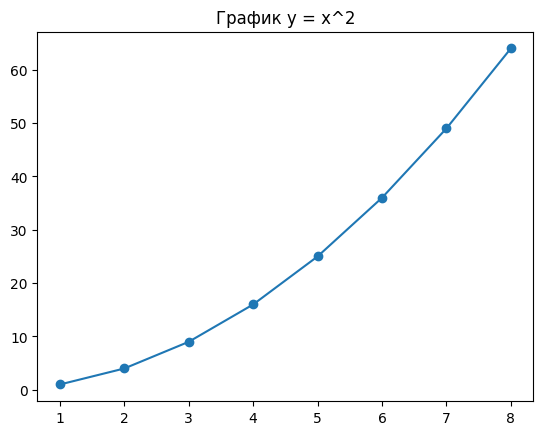

In [2]:
import matplotlib.pyplot as plt

x = [1, 2, 3, 4, 5, 6, 7, 8]
y = [i**2 for i in x]

plt.plot(x, y, marker="o")
plt.title("График y = x^2")
plt.show()

## Запуск программ на Python


### Как Python выполняет программы

- Python-программа – обычный текстовый файл с командами; по соглашению с расширением `.py`.
- Выполняет её **интерпретатор** – программа, которая запускает другие программы.
  Напрямую с «железом» Python не работает, интерпретатор стоит прослойкой.
- При установке Python на компьютер появляются сам интерпретатор и стандартная библиотека.
- Чтобы запустить программу, файл передают интерпретатору; команды выполняются сверху вниз.
- Реализаций интерпретатора несколько, разберём их через несколько слайдов.
  По умолчанию все используют **CPython**.


### Интерактивный режим (REPL)

Кроме запуска файлов у Python есть интерактивная оболочка: команды вводятся по одной
и выполняются сразу. Удобно, чтобы быстро что-то проверить.

1. Запустить в терминале: `python` (Windows) или `python3` (macOS и Linux).
2. Появится приглашение `>>>`:

   ```python
   >>> 2 + 3
   5
   >>> print("Привет, мир!")
   Привет, мир!
   ```

3. Выйти: `exit()`, либо `Ctrl+D` (macOS и Linux), либо `Ctrl+Z` и Enter (Windows).


### Взгляд Python на выполнение программы

- Python не выполняет код напрямую.
- Этапы запуска:
  1. **Компиляция** исходного кода (`.py`) в байт-код.
  2. **Исполнение байт-кода** виртуальной машиной Python.
- Байт-код = платформо-независимое представление кода.
- При импорте модулей байт-код сохраняется в файлы `.pyc` внутри папки `__pycache__`.
- Сохраняется для ускорения повторного запуска.
- Если исходный код меняется → байт-код пересоздаётся.
- Если используется другая версия Python → создаётся свой `.pyc`.
- При отсутствии `.pyc` программа всё равно работает (байт-код генерируется в памяти).


### Python Virtual Machine (PVM)

- После компиляции в байт-код → код передаётся **PVM** (Python Virtual Machine).
- PVM = часть интерпретатора, «движок исполнения» Python.
- Это цикл, который выполняет инструкции байт-кода одну за другой.
- Программисту не нужно ничего настраивать – всё происходит автоматически.

**Влияние на производительность:**

- Нет отдельного шага «сборки» (build/make), код выполняется сразу.
- Байт-код ≠ машинный код CPU → выполнение медленнее, чем на C/C++.

**Влияние на разработку:**

- Нет разделения на «среду разработки» и «среду исполнения» – это одно и то же.
- Быстрый цикл: «написал → запустил → проверил».
- Динамика: можно создавать и запускать код прямо во время работы программы (`eval`, `exec`).
- Всё (создание функций, классов, импорт модулей) происходит **во время выполнения**.

### Реализации Python: CPython и другие

Python – это **описание языка**, а не конкретная программа. Программ, умеющих
исполнять этот язык, несколько, и работают они по-разному: одна написана на C,
другая переводит код в машинный «на лету», третья умещается в микроконтроллер.

**CPython – эталонная реализация:**
- написана на C, работает на всех платформах, скачивается с python.org;
- самая полная поддержка стандартной библиотеки и C-расширений
  (NumPy, pandas и прочее собрано именно под неё);
- «эталонная» не фигура речи: спорные вопросы поведения языка решаются тем,
  как поступает CPython.

Почти весь код в мире пишется под CPython, остальные реализации берут под конкретную
задачу и осознанно. Всё, что мы делаем на курсе, – это CPython.


### PyPy – тот же язык, другой движок

PyPy добавляет **JIT-компиляцию**: интерпретатор замечает «горячие» участки кода
и переводит их в машинный код прямо во время работы. На длинных вычислительных
циклах из чистого Python выигрыш бывает в разы.

Цена, о которой обычно молчат:
- медленный старт – JIT нужно «разогреться», на коротких скриптах выигрыша нет;
- больше памяти;
- часть C-расширений либо не работает, либо теряет скорость.

Итог: PyPy оправдан для долгоживущих CPU-задач на чистом Python – и почти
бесполезен там, где всё считает NumPy.


### Ускорить, не меняя интерпретатор: Cython и Numba

- **Cython** – Python с типами, который компилируется в C-расширение. Так устроены
  внутренности многих известных библиотек.
- **Numba** – декоратор `@njit`: функция компилируется в машинный код при первом
  вызове. Хорошо работает на числовых циклах и массивах NumPy, плохо – на строках,
  словарях и объектах.

В обоих случаях ускоряется не «Python вообще», а конкретные горячие функции –
те, которые нашёл профилировщик. Как их искать, разберём в лекции про профилирование и качество кода.


In [ ]:
# numba не входит в зависимости курса – ячейка работает и без неё
try:
    from numba import njit
except ImportError:
    njit = None

import time


def kernel(n):
    acc = 0.0
    for i in range(n):
        acc += i * 0.5
    return acc


t0 = time.perf_counter()
kernel(5_000_000)
t_python = time.perf_counter() - t0

if njit is None:
    print("numba не установлена (pip install numba) – сравнение пропущено")
else:
    fast = njit(kernel)
    fast(10)                                  # первый вызов компилирует функцию
    t0 = time.perf_counter()
    fast(5_000_000)
    t_numba = time.perf_counter() - t0
    print("результаты совпадают:", kernel(1000) == fast(1000))
    print("numba быстрее чистого Python более чем в 10 раз:", t_python > 10 * t_numba)


результаты совпадают: True
numba быстрее чистого Python более чем в 10 раз: True


### Встраиваемый Python: MicroPython

Урезанный интерпретатор для микроконтроллеров – ESP32, Raspberry Pi Pico и подобных,
где счёт идёт на десятки килобайт памяти. Синтаксис тот же, но доступна лишь часть
стандартной библиотеки, а вместо привычных модулей – специальные (`machine`, `network`).

Тот же принцип, что и везде: язык один, реализация – под условия задачи.


### Исторические реализации

Их до сих пор перечисляют в учебниках наравне с остальными. Реальный статус:

| Реализация | Что это было | Статус |
|---|---|---|
| **Jython** | Python поверх JVM, интеграция с Java | развитие остановилось на Python **2.7** |
| **IronPython** | Python для .NET, интеграция с C# | жив, но нишевый |
| **Stackless** | форк CPython с лёгкими потоками | идеи ушли в сам язык: корутины и `asyncio` |

Если в 2026 году вам нужен Python – вы берёте CPython. Остальное требует
отдельного обоснования.


### Что меняется в самом CPython

**Встроенный JIT (PEP 744).** Начиная с 3.13 в CPython есть собственный
экспериментальный JIT-компилятор. Он выключен по умолчанию и собирается отдельным
флагом; кратного ускорения пока не даёт – это фундамент, на котором будут наращивать
оптимизации. Вопрос теперь не «появится ли JIT», а насколько его удастся раскачать.

**Свободнопоточный режим без GIL (PEP 703).** Отдельная сборка интерпретатора,
в которой снят глобальный замок: в 3.13 она экспериментальная, в 3.14 – официально
поддерживаемая, но всё ещё не сборка по умолчанию. Это означает, что потоки наконец
смогут считать по-настоящему параллельно. Почему это столько лет было невозможно –
разберём в лекции про параллелизм.

**Что при этом не меняется.** Байт-код остаётся стандартом: на нём держатся
переносимость и динамика языка. Аннотации типов так и останутся подсказками для
`mypy` и IDE – интерпретатор их не проверяет, и менять это не собираются.
Об этом в лекциях про типы данных и про качество кода.

Практический вывод на сегодня: следить стоит, переводить рабочий проект – рано.


### Самостоятельные исполняемые файлы
- **Обычные Python-программы**: запускаются только при установленном Python.  
- **Упакованные программы (frozen binaries)**: содержат в себе код + интерпретатор + библиотеки → запускаются без Python.  
- Используются для распространения приложений среди пользователей.  
- Инструменты:  
  - **PyInstaller, cx_Freeze** – Windows, macOS, Linux,  
  - **py2exe** – Windows,  
  - **py2app** – macOS,  
  - **Buildozer, Briefcase** – Android, iOS.  


### Какая версия нужна

- Курс идёт на **Python 3.13**; код рассчитан на **3.11 и новее**.
- Почему не «любая»: `match` появился в 3.10, запись типа `str | None` – тоже в 3.10,
  группы исключений – в 3.11. На 3.8 половина примеров просто не запустится.
- Версии выходят раз в год, в октябре, и поддерживаются пять лет.
- Что изменилось между версиями, смотрят в разделе **What's New** официальной
  документации – это первое место, куда стоит заглянуть перед обновлением проекта.

Установка по операционным системам и работа с несколькими версиями на одной машине
разбирались на **организационном занятии**. Короткая проверка прямо сейчас:

```bash
python --version     # Windows
python3 --version    # macOS и Linux
```


### Файлы программ и запуск из командной строки
- Интерактивный режим **не сохраняет** код, поэтому для повторного запуска его пишут
  в **файлы-модули** `.py`.
- Скрипт – «верхнеуровневый» файл, который запускают; модуль – файл, который **импортируют**.
- Базовый способ запуска: `python script1.py` (Windows) или `python3 script1.py`
  (macOS и Linux).
- Запускайте **в папке**, где лежит файл (сначала `cd` туда), либо указывайте полный путь.
- **Перенаправление вывода**: `python3 script1.py > saveit.txt`.


### Другие способы запуска
- **Клик по иконке файла** (Windows, macOS, иногда Linux).
- **IDLE** – простая графическая среда, которая ставится вместе с Python.
- **Другие IDE**: VS Code, PyCharm, Spyder.
- **Jupyter Notebooks** – интерактивные тетрадки, в которых идут эти лекции.
- **Упакованные программы** – интерпретатор и код в одном исполняемом файле (слайд выше).
- **Текстовые редакторы**, умеющие выполнить текущий файл.
- **Встраивание в другие языки** (C, C++, Java): интерпретатор подключается как библиотека.
- **Excel** – выполнение Python-выражений как части расчёта таблицы.
- **Веб-серверы**, запускающие скрипты в ответ на действия пользователя.


### Запуск кода из кода

Python умеет запускать Python: программа может выполнить другой файл или даже
текст кода, собранный во время работы. Дальше – четыре механизма, которыми это
делается, и чем они отличаются друг от друга.


### Перезагрузка модулей
- Повторный `import` **не перезапускает** файл.  
- Используйте `importlib.reload(module)`.  


In [ ]:
import scripts.test_script
from importlib import reload
reload(scripts.test_script)  # Выполнит актуальную версию файла повторно

### Атрибуты модуля
- Имена верхнего уровня становятся атрибутами модуля.  
- Доступ: `module.name` или `from module import name`.  


In [28]:
import scripts.test_script
scripts.test_script.title # доступ через пространство имён модуля

from scripts.test_script import title
title # прямой доступ

'Тестовый скрипт'

### exec: выполнение текста кода
- Запуск файла без импорта: `exec(open('file.py').read())`.  
- Исполняется в **текущем** пространстве имён.  


In [ ]:
from pathlib import Path

x = 999
script = Path("scripts") / "test_script.py"   # путь относительно папки lessons/
exec(script.read_text(encoding="utf-8"))      # выполняет код как «вставленный» здесь
print(x)                                      # 42: exec переопределил x в этом же пространстве имён


### Запуск через системные команды
- `os.system('python3 script.py')` – как в терминале (возвращает код статуса).  
- `subprocess.run([...])` – гибче: аргументы, вывод, ошибки, таймауты.  


## Частые ошибки и заблуждения

- **«Python – только для скриптов».** На Python пишут веб-сервисы, ML, инструменты – это
  универсальный язык.
- **«Интерпретируемый – значит без компиляции».** Python компилирует исходник в **байт-код**,
  который исполняет виртуальная машина PVM.
- **«Python медленный, поэтому непригоден».** Узкие места выносят в C-библиотеки (NumPy и др.);
  для большинства задач скорости достаточно.
- **Файл назван как модуль стандартной библиотеки.** Скрипт `random.py` рядом с вашим кодом
  «перебьёт» настоящий `random` – `import random` подхватит ваш файл.
- **Запуск не тем интерпретатором.** `python`, `python3` и интерпретатор из `.venv` – часто
  разные; проверяйте `python --version` и `which python` (Windows: `where python`).


## Мини-упражнение

Запустите один и тот же скрипт **тремя способами**: из файла в терминале (`python file.py`),
в интерактивной оболочке (`python`), и из ноутбука. Сравните, где удобнее что.

## Что почитать

- [Учебник Python](https://docs.python.org/3/tutorial/index.html) – официальный,
  главы 1–3 про запуск и первые программы.
- [General Python FAQ](https://docs.python.org/3/faq/general.html) – как устроен язык,
  реализации, байт-код.
- М. Лутц, «Изучаем Python» – главы 1–3: как Python выполняет программу.
